In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from vizman import viz
import pandas as pd
from tqdm import tqdm
import utils as ut
import scipy.signal as sig


In [11]:
# viz.set_visual_style()
# viz_sizes = viz.load_data_from_json("sizes.json")
# viz_colors = viz.load_data_from_json("colors.json")
# viz_cmaps = viz.give_colormaps()
# sns_kwargs = {"cmap": viz_cmaps["bw_lr"],
#               "xticklabels":False,
#               "yticklabels":False,
#               "rasterized":True}

In [12]:
# PARCELLATION = "schaefer100"

In [13]:
# lifespan_dataset = pd.read_pickle(f"../results/{PARCELLATION}/lifespan_dataset.pkl")

In [14]:
# N_REGIONS = 100
# N_SUBJECTS = lifespan_dataset.shape[0]
# connectivities = np.stack(lifespan_dataset["connectome"].values)

data_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_50.npy"
connectivities = np.load(data_path)


In [15]:
connectivities.shape

(225, 100, 100)

In [16]:
from numba import njit

In [22]:

@njit(nogil=True)
def simulate_stuart_landau(W, sim_time, dt, freq = 0.05, a = -0.1, noise = 0.001):
        
    # Number of neuronal populations
    n = W.shape[0]
    
    # Defines vectors to store activity. Storage starts in the points defined in store and store_time timesteps of activity are recorded
    Z = np.zeros((W.shape[0], int(np.floor(sim_time / dt))), dtype = np.complex128) # _)

    # Random initial conditions
    Z[:, 0] = 1e-5 * np.random.randn(n) + 1J*1e-5 * np.random.randn(n)

    # Runs simulations
    for st in range(1, int(np.floor(sim_time / dt))):

        # Gets input to each node
        input = np.sum(W * (Z[:, st-1][None, :] - Z[:, st-1][:, None]), axis = -1)

        # Calculates state changes  
        dz = Z[:, st-1] * (a + (2 * np.pi * freq * 1J) - np.abs(Z[:, st-1]**2)) + \
             input + noise * (np.random.randn(n) + 1J*np.random.randn(n))
        
        # Updates firing rate and state variable arrays using Euler method     
        Z[:, st] = Z[:, st-1] + dt * dz       
    
    return Z


In [17]:
import numpy as np
import scipy.signal as sig
from numba import njit
from sklearn.linear_model import LinearRegression


######################
## Evaluate network ##
######################
# Simulates and extracts relevant information

def evaluate_network(W, sim_time = 500, dt = 1e-2, K = 0.03, freq = 0.05, a = -0.1, noise = 0.001, estimate_DFA = False):

    # Simulates signal
    Z = simulate_stuart_landau(W = K * W, sim_time = sim_time + 10, dt = dt, freq = freq, a = a, noise = noise)

    # Removes initial transient
    Z = Z[:, int(10/dt):]
    signal = np.real(Z)

    if np.isnan(np.sum(signal)):
        return np.nan, np.nan * np.ones(W.shape[0]), np.nan * np.ones(W.shape[0])

    else:
        # Downsamples signal to sampling rates characteristic of BOLD -> makes further calculations much faster
        dt_ds = 0.5 # Sampling frequency of 2 Hz
        signal_ds = signal[:, ::int(dt_ds/dt)]

        # Filters signal in band of interest
        b, a = sig.butter(N = 2, Wn = [0.01, 0.1], btype = 'bandpass', fs = 1/dt_ds)
        signal_filt = sig.filtfilt(b, a, signal_ds, axis = -1)
        # Removes some signal from beginning and end to avoid edge effects from filter
        signal_filt = signal_filt[:, int(5/dt_ds):-int(5/dt_ds)]

        # Computes local and global metastability
        KOP_global, KOP_local = compute_KOP(signal = signal_ds, fs = 1/dt, W = W)

        meta_global = np.nanstd(KOP_global)
        meta_local = np.nanstd(KOP_local, axis = -1)

        if estimate_DFA:
            # Detrended fluctuation analysis
            ws = np.logspace(np.log10(50), np.log10(80), 5)
            DFA, _ = DFA_analysis(signal_ds, window_sizes = ws, fs = 1/dt_ds)
        else:
            DFA = np.nan * np.zeros(W.shape[0])

        return meta_global, meta_local, DFA



@njit(nogil=True)
def simulate_kuramoto(W, sim_time, dt, freq = 0.05, noise = 0.001):
        
    # Number of neuronal populations
    n = W.shape[0]
    
    # Defines vectors to store activity. Storage starts in the points defined in store and store_time timesteps of activity are recorded
    phase = np.zeros((W.shape[0], int(np.floor(sim_time / dt))))

    # Random initial conditions
    phase[:, 0] = np.random.randn(n)

    # Runs simulations
    for st in range(1, int(np.floor(sim_time / dt))):

        # Gets "input" to each node
        input = np.sum(W * np.sin(phase[:, st-1][None, :] - phase[:, st-1][:, None]), axis = -1)

        # Calculates state changes  
        dphase = 2 * np.pi * freq + input + noise * np.random.randn(n)
        
        # Updates firing rate and state variable arrays using Euler method     
        phase[:, st] = phase[:, st-1] + dt * dphase       
    
    return phase



##############
## Analysis ##
##############
def compute_KOP(signal, fs, W = None):

    # Computes global KOP
    KOP_global = np.abs(np.mean(sig.hilbert(signal, axis = -1)/np.abs(sig.hilbert(signal, axis = -1)), axis = 0))

    # Computes local KOP if connectivity matrix is given
    if W is None:
        KOP_local = np.nan * np.ones(signal.shape)
    else:
        KOP_local = np.abs((W @ (sig.hilbert(signal, axis = -1)/np.abs(sig.hilbert(signal, axis = -1))))/W.sum(0)[:, None])

    return KOP_global, KOP_local





def DFA_analysis(signal, window_sizes,
                 fs = 100, overlap = 0):
    
    # De-means signal
    signal -= np.nanmean(signal, axis = -1)[:, None]
    
    # Computes cumulative signal
    signal_prof = np.cumsum(signal, axis = -1)

    Ft_windows = np.zeros((signal_prof.shape[0], len(window_sizes)))
    window_counts = np.zeros(len(window_sizes))

    for w, window_size in enumerate(window_sizes):

        if signal_prof.shape[-1] > (window_size*fs):
                
            window_size = int(window_size*fs) # Gets window sizes in samples
            w_step = int((1 - overlap) * window_size)

            # Iterates over time-windows and calculates nFt
            for t in range(int(np.floor(signal_prof.shape[-1]/w_step))):
                # Defines signal window
                sig_window = signal_prof[:, int(t*w_step):(int(t*w_step)+window_size)]
                
                # Detrends signals in current window
                sig_window = sig.detrend(sig_window, axis = -1)

                # Computes fluctuation within current window
                Ft_windows[:, w] += np.std(sig_window, axis = -1)
                window_counts[w] += 1

    Ft_windows = Ft_windows / window_counts[None, :]

    # Iterates over time-series and estimates DFA exponents
    DFA = np.zeros(signal.shape[0])
    for n in range(Ft_windows.shape[0]):

        mask = (window_counts > 0)

        reg = LinearRegression().fit(np.log10(window_sizes)[mask][:, None], 
                                     np.log10(Ft_windows[n, :][mask])[:, None])
        
        DFA[n] = reg.coef_[0][0]
    
    return DFA, Ft_windows

In [23]:
sim_time = 5 # in seconds
dt = 0.1 # in seconds
Z = simulate_stuart_landau(W = connectivities[0,...], sim_time = sim_time, dt = dt)

In [24]:
connectivities[::10].shape

(23, 100, 100)

In [ ]:
K_vec = np.logspace(-4, 3, 41)
meta_stabilities = np.zeros((len(K_vec),212))
subset_W = connectivities[::10]
for subject in tqdm(np.arange(subset_W.shape[0])):
    W = subset_W[subject,...]
    meta_global_vec = np.zeros((len(K_vec)))
    for i, K in enumerate(K_vec):
        meta_stabilities[i,subject], _, _ = evaluate_network(W = W, K = K, sim_time = 500) # 9 min 30 sec

100%|██████████| 23/23 [09:26<00:00, 24.62s/it]


In [26]:
from pathlib import Path 
output_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/stuff/metastability")
output_path.mkdir(parents=True, exist_ok=True)

In [27]:
np.save(output_path / "metastabilities212.npy", meta_stabilities)

In [28]:
pd_data = pd.DataFrame()

In [29]:
from matplotlib.pyplot import colormaps as cm

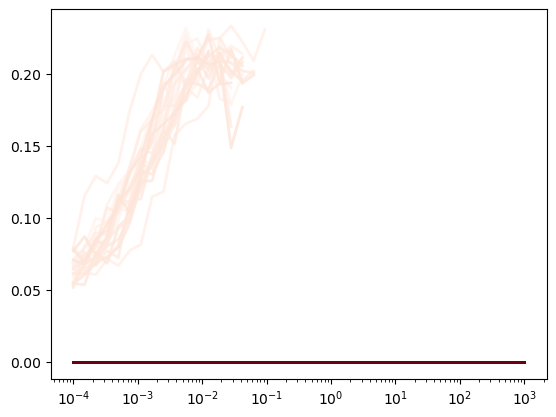

In [30]:
n_curves = meta_stabilities.shape[1]
greys = plt.get_cmap("Reds_r")
colors = [greys(1 - i/(n_curves - 1)*0.99) for i in range(n_curves)]
for i in range(n_curves):
    plt.plot(K_vec, meta_stabilities[:, i], color=colors[i], alpha = 0.8, lw=2)
plt.xscale("log")

In [31]:
meta_stabilities.argmax(0)

array([14, 14, 16, 15, 16, 15, 16, 15, 18, 12, 16, 15, 17, 15, 17, 16, 16,
       16, 17, 16, 13, 15, 16,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0])

<Axes: ylabel='Count'>

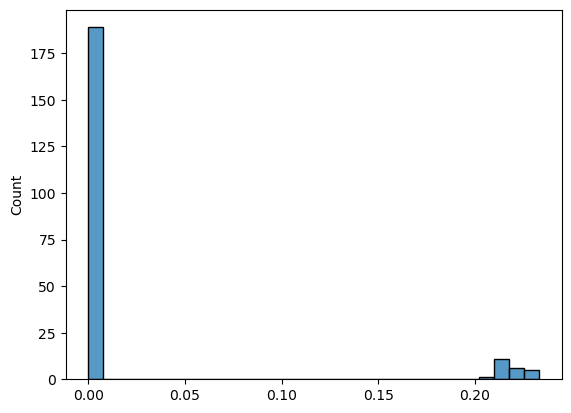

In [32]:
sns.histplot(np.nanmax(meta_stabilities,0))

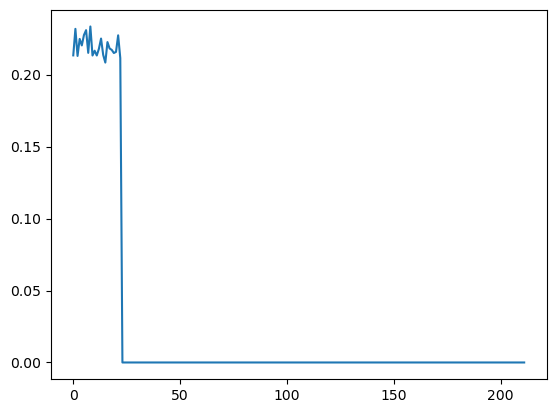

In [33]:
plt.plot(np.nanmax(meta_stabilities,0))